In [1]:
# 01. Разведочный анализ данных и подготовка

#**Цель:** Загрузить данные, изучить структуру, проанализировать пропуски, выбросы и понять особенности датасета SDWPF для задачи прогнозирования pitch и yaw.

In [2]:
import sys
sys.path.append('..')  # для импорта из src

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_style("whitegrid")
%matplotlib inline

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [3]:
# Пути к файлам
data_path = Path('../data')

main_file = data_path / 'wtbdata_245days.csv'
location_file = data_path / 'sdwpf_baidukddcup2022_turb_location.csv'

# Загрузка
df = pd.read_csv(main_file)
loc = pd.read_csv(location_file)

print(f"Основные данные: {df.shape}")
print(f"Данные о расположении турбин: {loc.shape}")
print("\nСтолбцы основных данных:")
print(df.columns.tolist())

Основные данные: (4727520, 13)
Данные о расположении турбин: (134, 3)

Столбцы основных данных:
['TurbID', 'Day', 'Tmstamp', 'Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'Patv']


In [4]:
print("=== Информация о данных ===")
print(df.info())

print("\n=== Первые 5 строк ===")
display(df.head())

print("\n=== Статистика ===")
display(df.describe().round(3))

=== Информация о данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727520 entries, 0 to 4727519
Data columns (total 13 columns):
 #   Column   Dtype  
---  ------   -----  
 0   TurbID   int64  
 1   Day      int64  
 2   Tmstamp  object 
 3   Wspd     float64
 4   Wdir     float64
 5   Etmp     float64
 6   Itmp     float64
 7   Ndir     float64
 8   Pab1     float64
 9   Pab2     float64
 10  Pab3     float64
 11  Prtv     float64
 12  Patv     float64
dtypes: float64(10), int64(2), object(1)
memory usage: 468.9+ MB
None

=== Первые 5 строк ===


,TurbID,Day,Tmstamp,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
0,1,1,00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,00:10,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66
2,1,1,00:20,6.27,-2.18,30.60,41.63,20.91,1.0,1.0,1.0,-0.24,509.76
3,1,1,00:30,6.42,-0.73,30.52,41.52,20.91,1.0,1.0,1.0,-0.26,542.53
4,1,1,00:40,6.25,0.89,30.49,41.38,20.91,1.0,1.0,1.0,-0.23,509.36



=== Статистика ===


,TurbID,Day,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
count,4727520.000,4727520.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000,4678002.000
mean,67.500,123.000,5.028,0.498,41.107,27.397,188.583,26.854,26.839,26.827,-13.239,350.446
std,38.681,70.725,3.394,31.603,85.290,18.328,163.246,38.836,38.829,38.822,70.442,424.993
min,1.000,1.000,0.000,-3030.460,-273.030,-273.170,-884.860,-10.000,-10.000,-10.000,-624.980,-9.330
25%,34.000,62.000,2.240,-3.830,14.050,20.060,63.020,0.010,0.010,0.010,-38.610,-0.300
50%,67.500,123.000,4.340,-0.230,25.730,30.080,194.790,0.540,0.540,0.540,-0.300,179.080
75%,101.000,184.000,7.010,3.420,32.730,36.820,321.960,83.990,83.980,83.980,-0.030,547.660
max,134.000,245.000,26.290,2266.950,394.330,324.210,700.620,99.980,99.980,99.980,485.200,1567.020


Пропуски по столбцам:


,Пропуски,Процент
Wspd,49518,1.047
Wdir,49518,1.047
Etmp,49518,1.047
Itmp,49518,1.047
Ndir,49518,1.047
Pab1,49518,1.047
Pab2,49518,1.047
Pab3,49518,1.047
Prtv,49518,1.047
Patv,49518,1.047


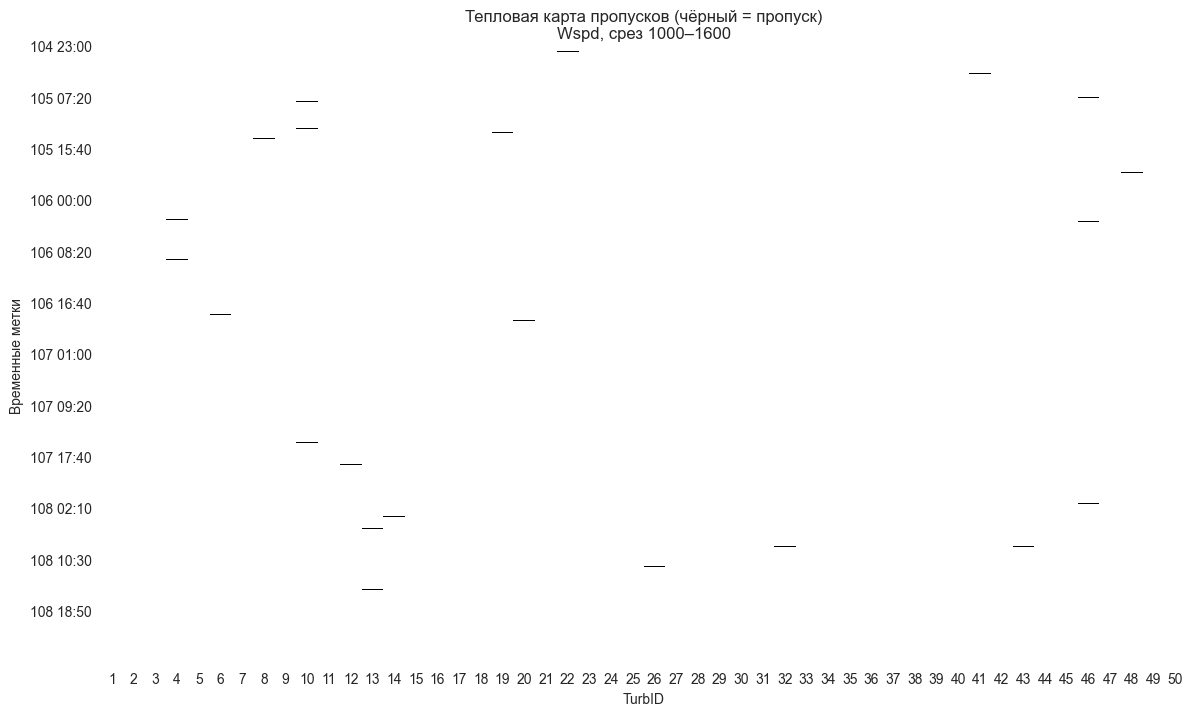

In [5]:
# Пропуски
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(3)

missing_df = pd.DataFrame({
    'Пропуски': missing,
    'Процент': missing_percent
}).sort_values('Пропуски', ascending=False)

print("Пропуски по столбцам:")
display(missing_df[missing_df['Пропуски'] > 0])

# === ИСПРАВЛЕННАЯ ТЕПЛОВАЯ КАРТА ПРОПУСКОВ ===

# Создаём комбинированный временной индекс
df['datetime'] = df['Day'].astype(str) + ' ' + df['Tmstamp']
df_temp = df.pivot_table(index='datetime', columns='TurbID', values='Wspd')

# Берём срез (например, с 1000 по 1500 строку)
plt.figure(figsize=(14, 8))
sns.heatmap(df_temp.iloc[1000:1600, :50].isnull(), 
            cmap='binary', 
            cbar=False,
            yticklabels=50)  # показываем меньше меток по Y

plt.title('Тепловая карта пропусков (чёрный = пропуск)\nWspd, срез 1000–1600')
plt.xlabel('TurbID')
plt.ylabel('Временные метки')
plt.show()

In [6]:
# === Обработка пропусков ===

print("Обработка пропусков...")

# 1. Заполняем пропуски в числовых колонках (кроме целевых)
numeric_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Prtv', 'Patv']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())   # или .mean(), или forward/backward fill

# 2. Для целевых переменных (Pab1, Pab2, Pab3, Ndir) — тоже медианой
target_cols = ['Pab1', 'Pab2', 'Pab3', 'Ndir']
for col in target_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. Проверяем, что пропусков больше нет
print("Пропуски после обработки:")
print(df.isnull().sum().sum())  # должно быть 0

# Альтернатива: можно использовать интерполяцию по времени
# df = df.groupby('TurbID').apply(lambda group: group.interpolate(method='linear'))

Обработка пропусков...
Пропуски после обработки:
0


Статистика целевых переменных:


,Pab1,Pab2,Pab3,Ndir
count,4727520.000,4727520.000,4727520.000,4727520.000
mean,26.578,26.564,26.551,188.648
std,38.725,38.718,38.711,162.390
min,-10.000,-10.000,-10.000,-884.860
25%,0.010,0.010,0.010,65.340
50%,0.540,0.540,0.540,194.790
75%,83.960,83.960,83.960,320.830
max,99.980,99.980,99.980,700.620


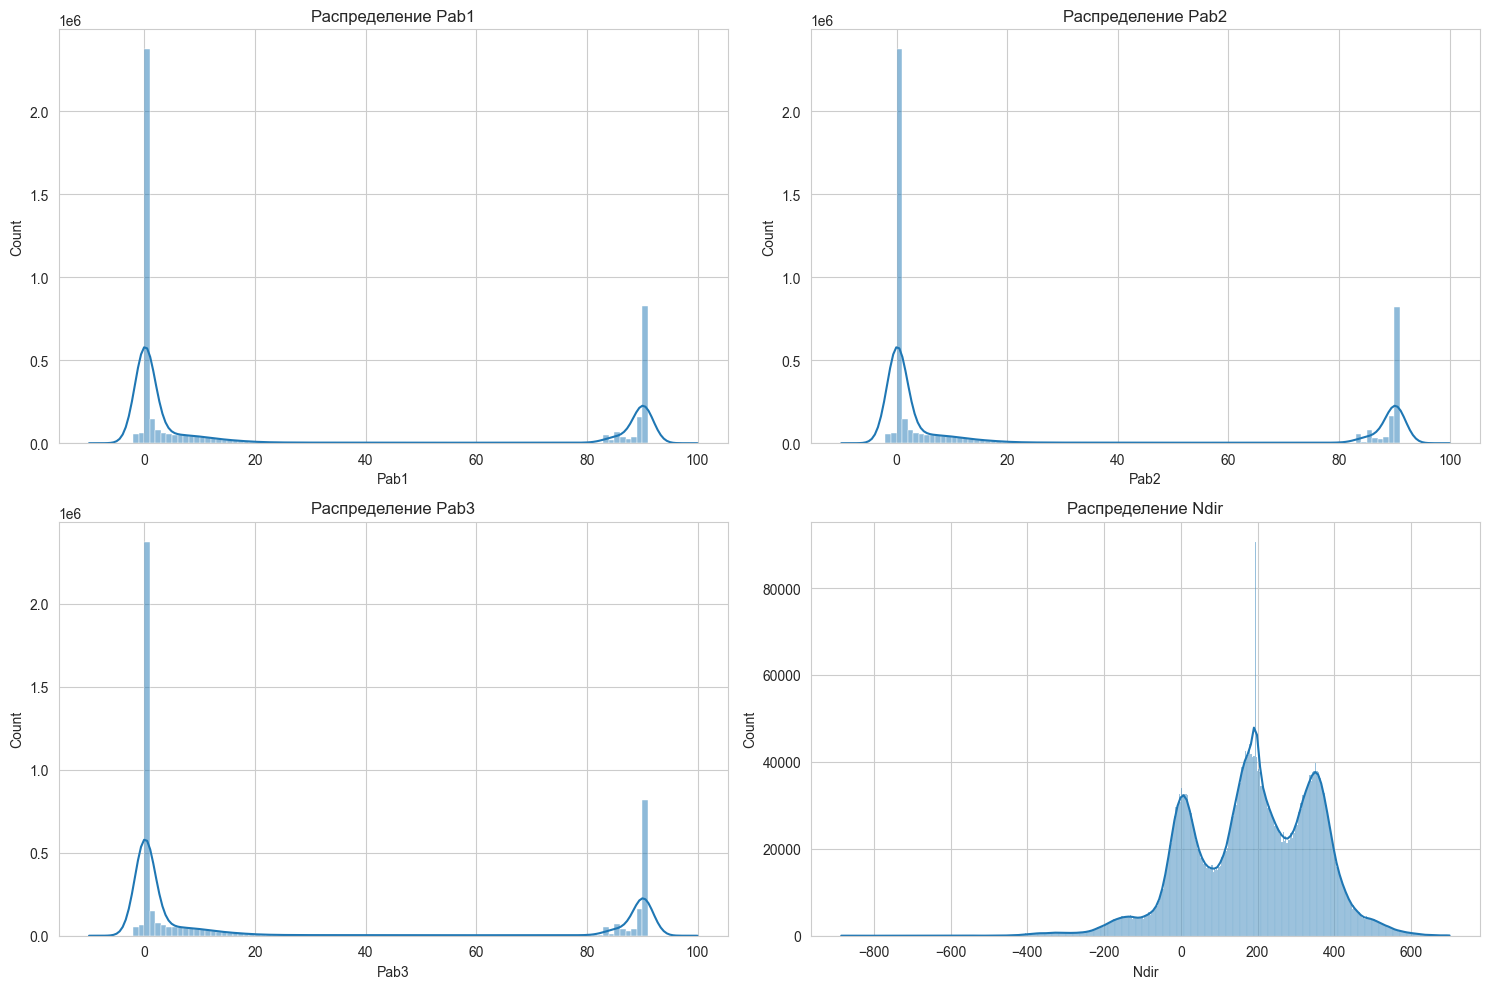

In [7]:
target_cols = ['Pab1', 'Pab2', 'Pab3', 'Ndir']

print("Статистика целевых переменных:")
display(df[target_cols].describe().round(3))

# Распределения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

In [8]:
print("Количество уникальных турбин:", df['TurbID'].nunique())
print("\nРасположение турбин:")
display(loc.head())
print(f"\nДиапазон координат x: {loc['x'].min():.2f} — {loc['x'].max():.2f}")
print(f"Диапазон координат y: {loc['y'].min():.2f} — {loc['y'].max():.2f}")

Количество уникальных турбин: 134

Расположение турбин:


,TurbID,x,y
0,1,3349.8515,5939.23193
1,2,3351.0017,6416.64673
2,3,3314.7797,6892.18395
3,4,3352.0940,7366.14203
4,5,3355.3420,7841.20175



Диапазон координат x: 0.00 — 5501.45
Диапазон координат y: 0.00 — 12121.00
